In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [58]:
df = pd.read_csv("imdb_top_1000.csv") 
df.head(10)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905"
6,https://m.media-amazon.com/images/M/MV5BNGNhMD...,Pulp Fiction,1994,A,154 min,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,"107,928,762"
7,https://m.media-amazon.com/images/M/MV5BNDE4OT...,Schindler's List,1993,A,195 min,"Biography, Drama, History",8.9,"In German-occupied Poland during World War II,...",94.0,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall,1213505,"96,898,818"
8,https://m.media-amazon.com/images/M/MV5BMjAxMz...,Inception,2010,UA,148 min,"Action, Adventure, Sci-Fi",8.8,A thief who steals corporate secrets through t...,74.0,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,2067042,"292,576,195"
9,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Fight Club,1999,A,139 min,Drama,8.8,An insomniac office worker and a devil-may-car...,66.0,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,1854740,"37,030,102"


In [59]:
# Basic info
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [60]:
df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [61]:
df['Gross'] = df['Gross'].str.replace(',', '')
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')

In [62]:
df['Runtime'] = df['Runtime'].str.replace(' min', '')
df['Runtime'] = df['Runtime'].astype(int)

In [63]:
df['Gross'].fillna(df['Gross'].mean(), inplace=True)
df['Meta_score'].fillna(df['Meta_score'].mean(), inplace=True)
df['Certificate'].fillna(df['Certificate'].mode()[0], inplace=True)

In [64]:
df.isnull().sum()

Poster_Link      0
Series_Title     0
Released_Year    0
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Overview         0
Meta_score       0
Director         0
Star1            0
Star2            0
Star3            0
Star4            0
No_of_Votes      0
Gross            0
dtype: int64

In [65]:
top_rated = df.sort_values(by='IMDB_Rating', ascending=False).head(10)
top_rated[['Series_Title', 'IMDB_Rating']]

,Series_Title,IMDB_Rating
0,The Shawshank Redemption,9.3
1,The Godfather,9.2
2,The Dark Knight,9.0
3,The Godfather: Part II,9.0
4,12 Angry Men,9.0
5,The Lord of the Rings: The Return of the King,8.9
6,Pulp Fiction,8.9
7,Schindler's List,8.9
10,The Lord of the Rings: The Fellowship of the Ring,8.8
11,Forrest Gump,8.8


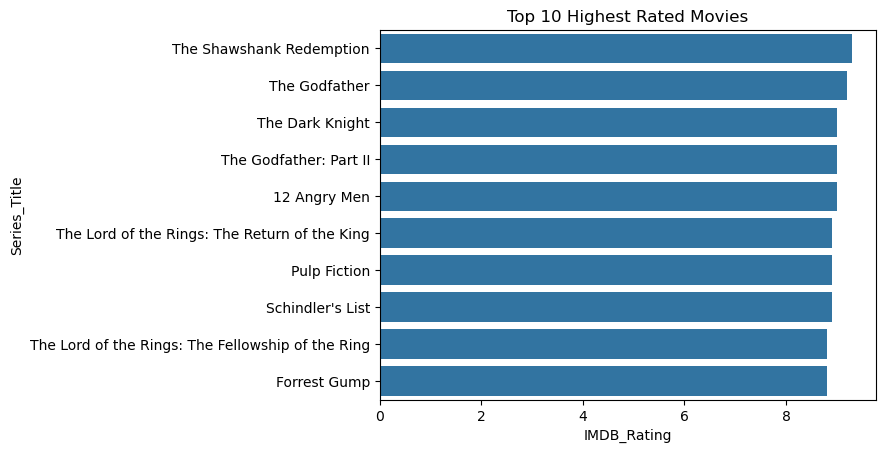

In [66]:
plt.figure()
sns.barplot(x='IMDB_Rating', y='Series_Title', data=top_rated)
plt.title("Top 10 Highest Rated Movies")
plt.show()

In [67]:
popular = df.sort_values(by='No_of_Votes', ascending=False).head(10)
popular[['Series_Title', 'No_of_Votes']]

,Series_Title,No_of_Votes
0,The Shawshank Redemption,2343110
2,The Dark Knight,2303232
8,Inception,2067042
9,Fight Club,1854740
6,Pulp Fiction,1826188
11,Forrest Gump,1809221
14,The Matrix,1676426
10,The Lord of the Rings: The Fellowship of the Ring,1661481
5,The Lord of the Rings: The Return of the King,1642758
1,The Godfather,1620367


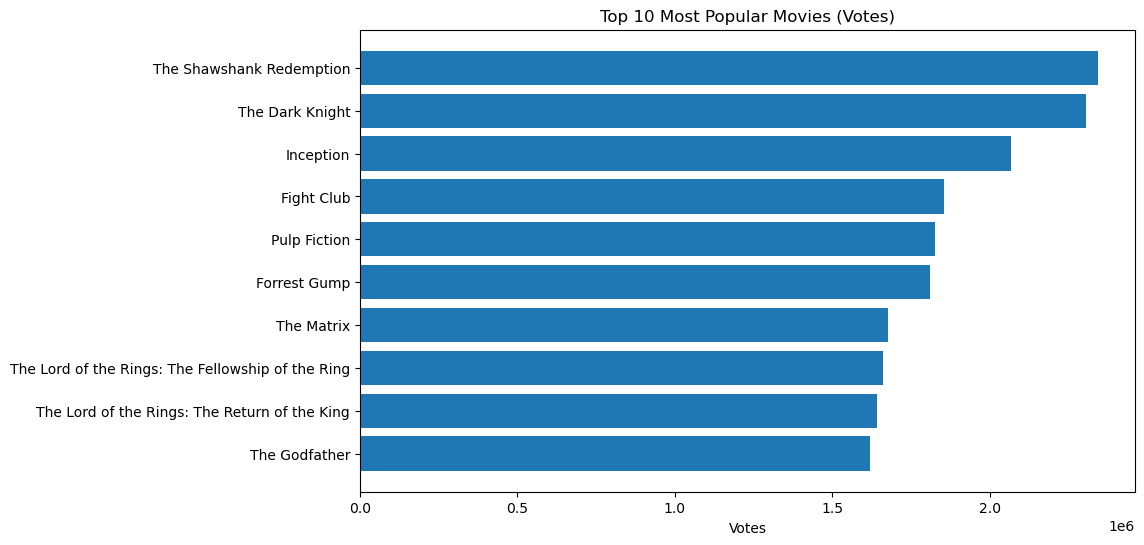

In [68]:


plt.figure(figsize=(10,6))

plt.barh(popular_sorted['Series_Title'], popular_sorted['No_of_Votes'])

plt.title("Top 10 Most Popular Movies (Votes)")
plt.xlabel("Votes")

plt.show()

In [69]:
all_stars = pd.concat([df['Star1'], df['Star2'], df['Star3'], df['Star4']])
top_stars = all_stars.value_counts().head(10)
top_stars

Robert De Niro       17
Tom Hanks            14
Al Pacino            13
Clint Eastwood       12
Brad Pitt            12
Leonardo DiCaprio    11
Matt Damon           11
Christian Bale       11
James Stewart        10
Ethan Hawke           9
Name: count, dtype: int64

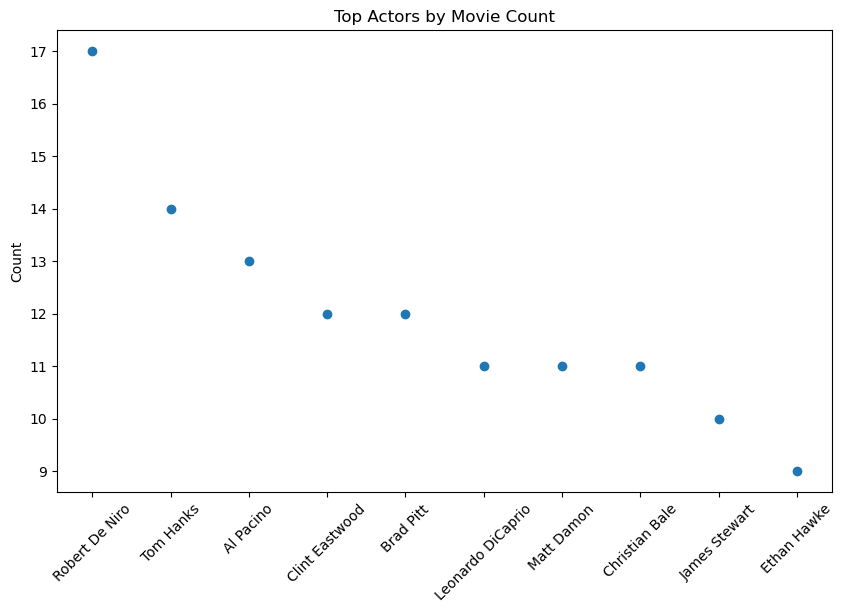

In [70]:
plt.figure(figsize=(10,6))

plt.scatter(top_stars.index, top_stars.values)

plt.title("Top Actors by Movie Count")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [71]:
long_movies = df.sort_values(by='Runtime', ascending=False).head(10)
long_movies[['Series_Title', 'Runtime']]

,Series_Title,Runtime
140,Gangs of Wasseypur,321
812,Hamlet,242
314,Gone with the Wind,238
71,Once Upon a Time in America,229
116,Lawrence of Arabia,228
247,Lagaan: Once Upon a Time in India,224
552,The Ten Commandments,220
300,Ben-Hur,212
156,"Swades: We, the People",210
484,The Irishman,209


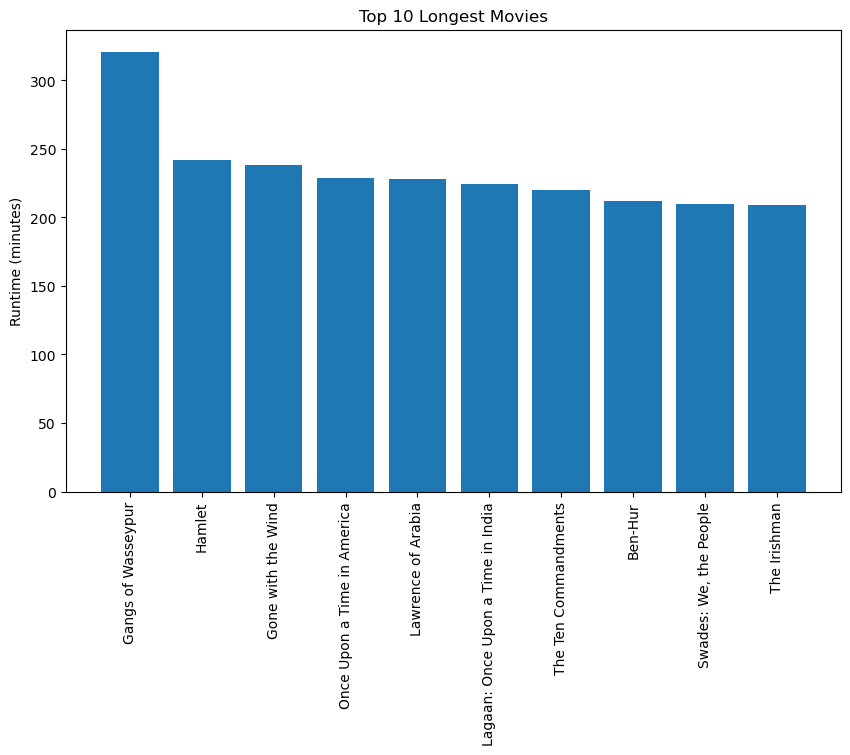

In [72]:

plt.figure(figsize=(10,6))

plt.bar(long_movies['Series_Title'], long_movies['Runtime'])
plt.xticks(rotation=90)

plt.title("Top 10 Longest Movies")
plt.ylabel("Runtime (minutes)")

plt.show()

In [73]:
top_gross = df.sort_values(by='Gross', ascending=False).head(10)

In [74]:
top_gross = df.sort_values(by='Gross', ascending=False).head(10)

top_gross[['Series_Title', 'Gross']]

,Series_Title,Gross
477,Star Wars: Episode VII - The Force Awakens,936662225.0
59,Avengers: Endgame,858373000.0
623,Avatar,760507625.0
60,Avengers: Infinity War,678815482.0
652,Titanic,659325379.0
357,The Avengers,623279547.0
891,Incredibles 2,608581744.0
2,The Dark Knight,534858444.0
582,Rogue One,532177324.0
63,The Dark Knight Rises,448139099.0


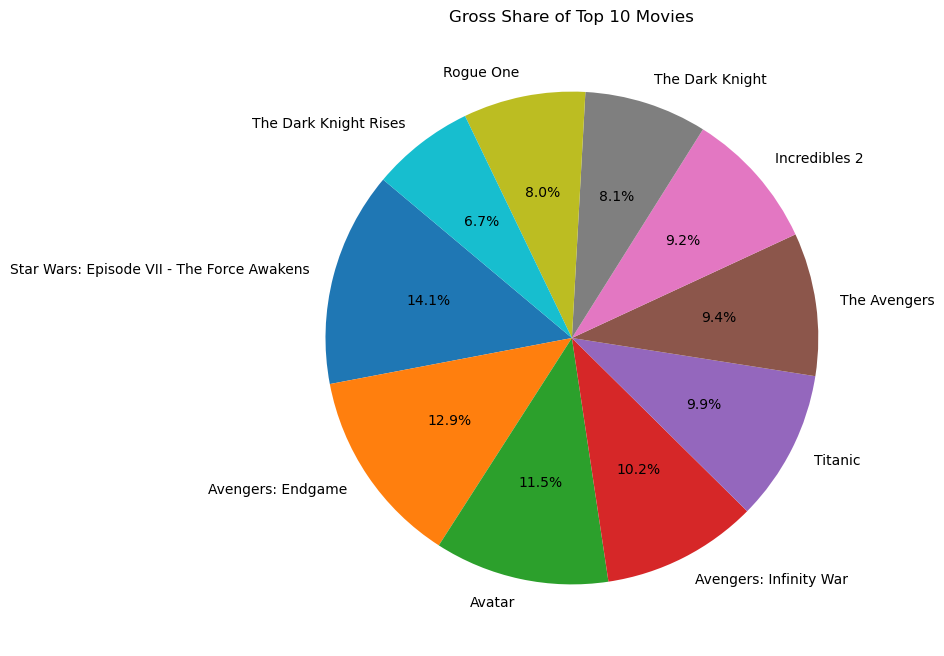

In [75]:
plt.figure(figsize=(8,8))

plt.pie(
    top_gross['Gross'],   # ✅ correct variable name
    labels=top_gross['Series_Title'],
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Gross Share of Top 10 Movies")
plt.show()

In [76]:
# Split genres
genre_series = df['Genre'].str.split(',', expand=True).stack().str.strip()
genre_counts = genre_series.value_counts()
genre_counts

Drama        724
Comedy       233
Crime        209
Adventure    196
Action       189
Thriller     137
Romance      125
Biography    109
Mystery       99
Animation     82
Sci-Fi        67
Fantasy       66
History       56
Family        56
War           51
Music         35
Horror        32
Western       20
Film-Noir     19
Sport         19
Musical       17
Name: count, dtype: int64

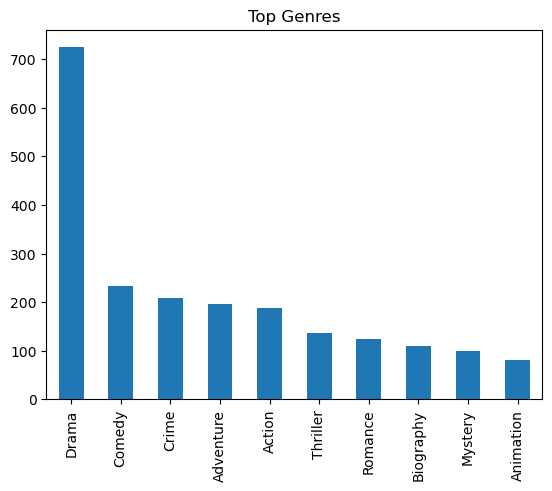

In [77]:
plt.figure()
genre_counts.head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

In [78]:
df['Main_Genre'] = df['Genre'].apply(lambda x: x.split(',')[0])

genre_rating = df.groupby('Main_Genre')['IMDB_Rating'].mean().sort_values(ascending=False)
genre_rating.head(10)

Main_Genre
Western      8.350000
Crime        8.016822
Fantasy      8.000000
Mystery      7.975000
Film-Noir    7.966667
Drama        7.957439
Action       7.949419
Biography    7.938636
Adventure    7.937500
Animation    7.930488
Name: IMDB_Rating, dtype: float64

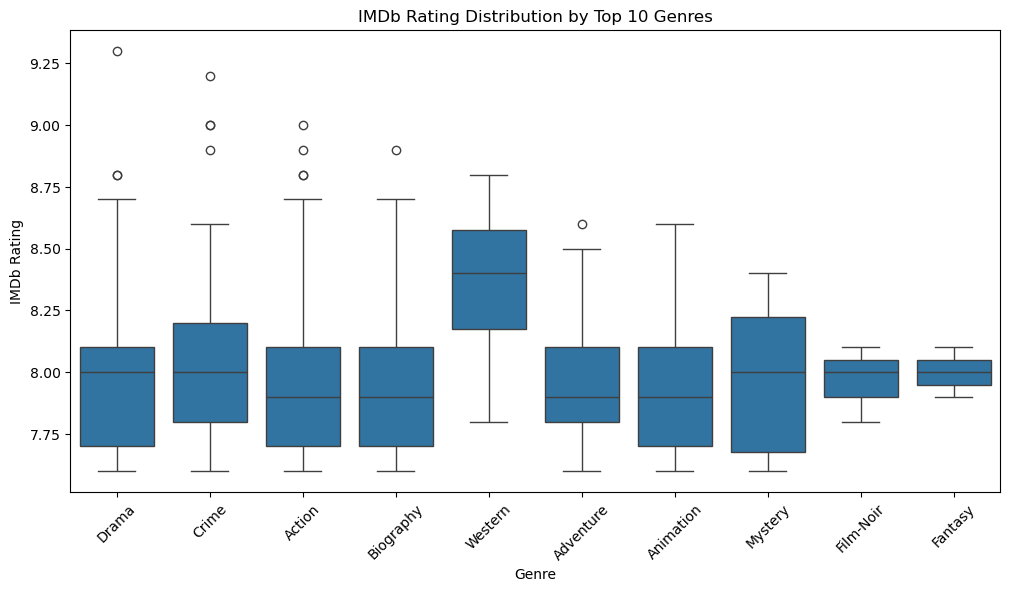

In [79]:
# Top 10 genres based on average rating
top_genres = genre_rating.head(10).index

# Filter dataset for those genres
genre_df = df[df['Main_Genre'].isin(top_genres)]

# Box Plot
plt.figure(figsize=(12,6))
sns.boxplot(x='Main_Genre', y='IMDB_Rating', data=genre_df)

plt.title("IMDb Rating Distribution by Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("IMDb Rating")
plt.xticks(rotation=45)

plt.show()

In [80]:
year_count = df['Released_Year'].value_counts().sort_values(ascending=False)
year_count


Released_Year
2014    32
2004    31
2009    29
2016    28
2013    28
        ..
1926     1
1936     1
1924     1
1921     1
PG       1
Name: count, Length: 100, dtype: int64

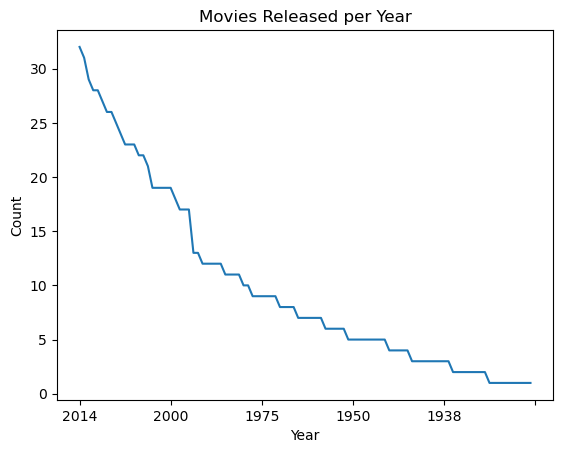

In [81]:

plt.figure()
year_count.plot()
plt.title("Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [82]:
df['Certificate'].value_counts()

Certificate
U           335
A           197
UA          175
R           146
PG-13        43
PG           37
Passed       34
G            12
Approved     11
TV-PG         3
GP            2
TV-14         1
16            1
TV-MA         1
Unrated       1
U/A           1
Name: count, dtype: int64

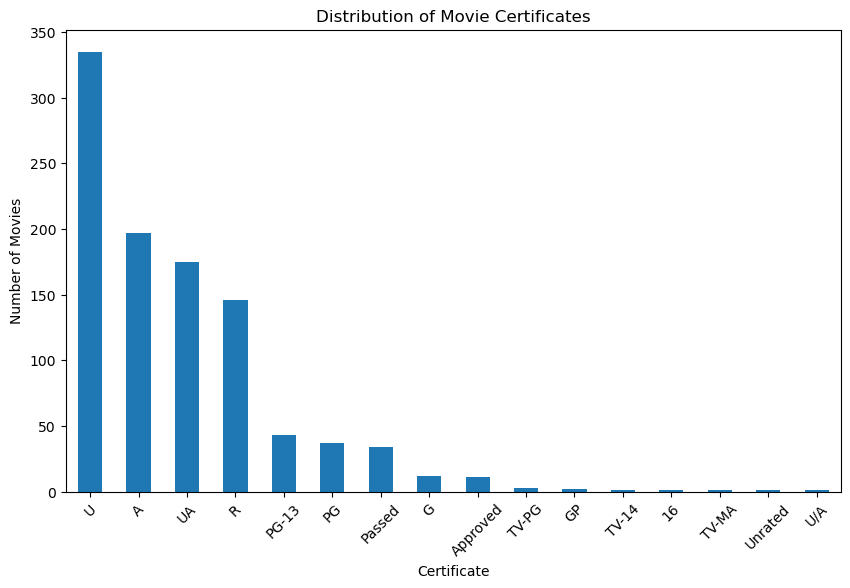

In [83]:
# Count certificates
cert_counts = df['Certificate'].value_counts()

# Bar Graph
plt.figure(figsize=(10,6))
cert_counts.plot(kind='bar')

plt.title("Distribution of Movie Certificates")
plt.xlabel("Certificate")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.show()

In [84]:
cert_rating = df.groupby('Certificate')['IMDB_Rating'].mean().sort_values(ascending=False)
cert_rating

Certificate
TV-14       8.300000
16          8.100000
TV-MA       8.100000
Unrated     8.100000
Passed      8.020588
G           8.000000
A           7.998985
U           7.963284
UA          7.957143
Approved    7.945455
PG          7.927027
TV-PG       7.900000
R           7.869863
GP          7.850000
PG-13       7.797674
U/A         7.600000
Name: IMDB_Rating, dtype: float64

In [85]:
top_directors = df['Director'].value_counts().head(10)
top_directors

Director
Alfred Hitchcock     14
Steven Spielberg     13
Hayao Miyazaki       11
Martin Scorsese      10
Akira Kurosawa       10
Stanley Kubrick       9
Billy Wilder          9
Woody Allen           9
Christopher Nolan     8
Quentin Tarantino     8
Name: count, dtype: int64

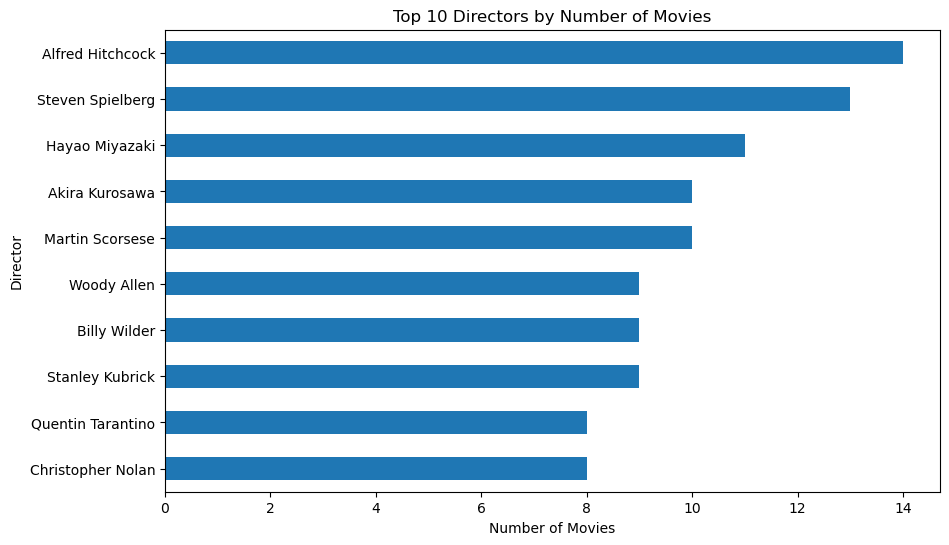

In [86]:
# Top 10 directors graph
plt.figure(figsize=(10,6))

top_directors.sort_values().plot(kind='barh')

plt.title("Top 10 Directors by Number of Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Director")

plt.show()

In [87]:
director_rating = df.groupby('Director')['IMDB_Rating'].mean().sort_values(ascending=False)
director_rating.head(10)

Director
Frank Darabont        8.95
Irvin Kershner        8.70
Lana Wachowski        8.70
George Lucas          8.60
Roberto Benigni       8.60
Masaki Kobayashi      8.60
Thomas Kail           8.60
Sudha Kongara         8.60
Fernando Meirelles    8.60
Roger Allers          8.50
Name: IMDB_Rating, dtype: float64

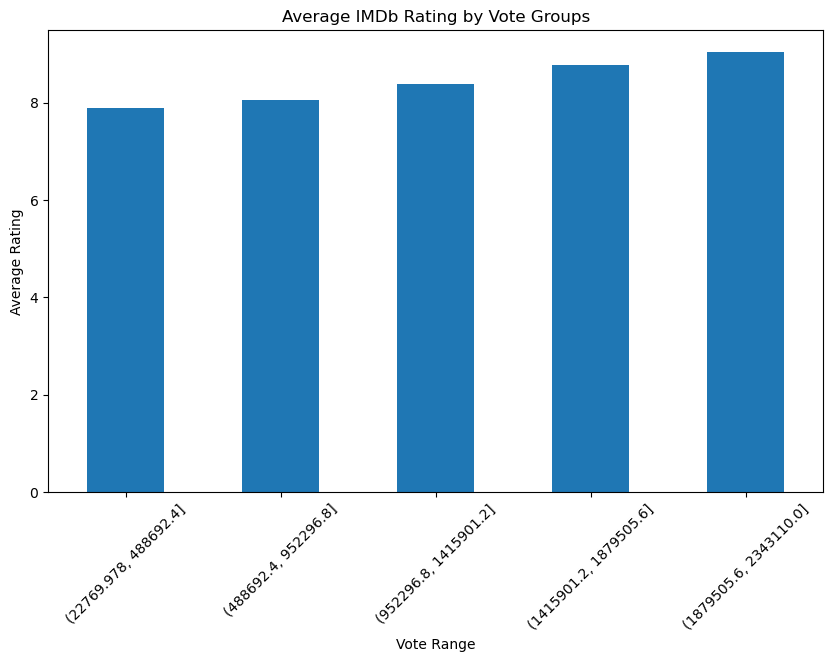

In [93]:
# Create vote bins
df['Vote_Group'] = pd.cut(
    df['No_of_Votes'],
    bins=5
)

# Average rating by vote group
vote_rating = df.groupby('Vote_Group')['IMDB_Rating'].mean()

# Bar Graph
plt.figure(figsize=(10,6))

vote_rating.plot(kind='bar')

plt.title("Average IMDb Rating by Vote Groups")
plt.xlabel("Vote Range")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.show()

In [89]:
top_gross = df.sort_values(by='Gross', ascending=False).head(10)
top_gross[['Series_Title', 'Gross']]

,Series_Title,Gross
477,Star Wars: Episode VII - The Force Awakens,936662225.0
59,Avengers: Endgame,858373000.0
623,Avatar,760507625.0
60,Avengers: Infinity War,678815482.0
652,Titanic,659325379.0
357,The Avengers,623279547.0
891,Incredibles 2,608581744.0
2,The Dark Knight,534858444.0
582,Rogue One,532177324.0
63,The Dark Knight Rises,448139099.0


In [90]:
# Best director based on average rating
best_director = df.groupby('Director')['IMDB_Rating'].mean().idxmax()
print("Best Director =", best_director)

Best Director = Frank Darabont


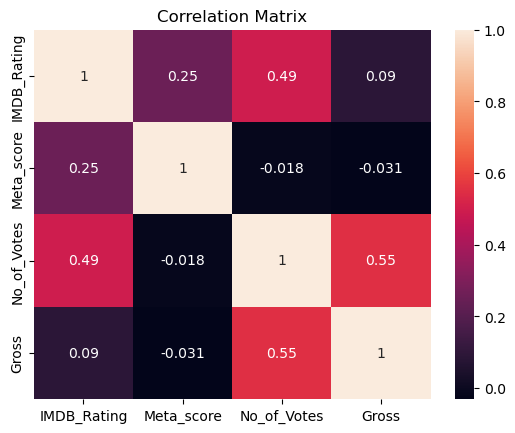

In [91]:
corr = df[['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

------------------------------------------------------------------------------------------------------------
### REPORTS ON THE ANALYSIS :
- The dataset contains 1000 movies, and after cleaning, missing values in Gross and Meta_score were handled using average values.
- Among all movies, ratings mostly range between 8.0 to 9.3, showing that the dataset contains highly rated films.
-The Shawshank Redemption is the highest-rated movie with a rating of 9.3, followed by The Godfather (9.2) and The Dark Knight (9.0).
- Based on popularity (votes), The Shawshank Redemption again ranks first with around 2.34 million votes, followed by The Dark Knight (2.30 million) and Inception (2.06 million).
- In terms of actors, Robert De Niro appeared the most (17 movies), followed by Tom Hanks (14) and Al Pacino (13).
- The longest movie in the dataset is Gangs of Wasseypur with 321 minutes, followed by Hamlet (242 minutes) and Gone with the Wind (238 minutes).
- In terms of box office collection, Star Wars: The Force Awakens earned the highest gross of about $936 million, followed by Avengers: Endgame ($858 million) and Avatar ($760 million).
- Genre analysis shows that Drama is the most common genre with 724 movies, followed by Comedy (233) and Crime (209).
- However, based on average ratings, Western genre has the highest rating (8.35), followed by Crime (8.01) and Fantasy (8.00).
- The number of movies released was highest in recent years like 2014 (32 movies), 2004 (31 movies), and 2009 (29 movies).
- Among certifications, U (234 movies), A (197), and UA (175) are the most common categories.
- From the director analysis, Alfred Hitchcock (14 movies) and Steven Spielberg (13 movies) have directed the most films in the dataset.
- From correlation analysis, it is observed that there is a strong positive relationship between Number of Votes and Gross earnings.
- There is a moderate relationship between Ratings and Votes, while Meta_score has a weaker relationship with other variables.
- This shows that movies with higher popularity (votes) tend to generate higher revenue.
------------------------------------------------------------------------------------------------------------
### Conclusion :
- The analysis shows that most movies in the dataset are highly rated (above 8.0), indicating top-quality content.
- The Shawshank Redemption stands out as both the highest-rated and most popular movie.
- Actors like Robert De Niro and Tom Hanks and directors like Alfred Hitchcock and Steven Spielberg play a major role in successful films.
- Even though Drama is the most common genre, Western genre has the highest average rating, showing quality over quantity.
- One important finding is that Number of Votes strongly influences Gross earnings.
This means that more popular movies tend to earn more money, even if their ratings are similar.
- The analysis also shows that recent years produced more top movies, but success is not limited to new films.
- Overall, the success of a movie depends more on audience engagement (votes/popularity) rather than just ratings or release year.
- Continuous popularity and audience interest play a key role in determining a movie’s success.